In [52]:
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import torch.nn
import pandas
import numpy
import torch.nn.functional
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import mean_absolute_error
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import yfinance
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings(action='ignore')
warnings.filterwarnings(action='ignore')
import matplotlib.pyplot as plt

In [3]:
loan_data=pandas.read_csv('/Users/kbh/Downloads/lending club/all_clean_current_final_out_data.csv')
# loan_data=pandas.read_csv('/Users/kbh/Downloads/lending club/rate_final_temp_data.csv')
loan_data['issue_d'].dropna(inplace=True)
loan_data['target']=loan_data['total_rec_prncp']/loan_data['funded_amnt']
def clean_data(x) :
    x.replace([numpy.inf],0,inplace=True)
    x.replace([numpy.NAN],0,inplace=True)
clean_data(loan_data)

In [6]:
def clean_data(x) :
    x.replace([numpy.inf],0,inplace=True)
    x.replace([numpy.NAN],0,inplace=True)
y_temp=loan_data['total_rec_prncp']/loan_data['funded_amnt']
clean_data(y_temp)
id=loan_data['id']
loan_data.drop('id',axis=1,inplace=True)
select_feature='''
loan_amnt
term
int_rate
installment
sub_grade
emp_length
home_ownership
annual_inc
verification_status
purpose
dti
delinq_2yrs
fico_range_high
mths_since_last_delinq
open_acc
pub_rec
revol_util
total_acc
initial_list_status
last_fico_range_high
collections_12_mths_ex_med
mths_since_last_major_derog
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
max_bal_bc
all_util
total_rev_hi_lim
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc_util
chargeoff_within_12_mths
delinq_amnt
mo_sin_old_il_acct
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_inq
mths_since_recent_revol_delinq
num_accts_ever_120_pd
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_il_tl
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_90g_dpd_24m
num_tl_op_past_12m
pct_tl_nvr_dlq
percent_bc_gt_75
pub_rec_bankruptcies
tax_liens
tot_hi_cred_lim
total_bal_ex_mort
total_bc_limit
total_il_high_credit_limit
revol_bal_joint
sec_app_fico_range_low
sec_app_fico_range_high
sec_app_inq_last_6mths
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_collections_12_mths_ex_med
'''
select_feature=select_feature.strip().split('\n')
x_temp=loan_data[select_feature].reset_index(drop=True)

In [8]:
x_temp['bar_ex_mort_year']=x_temp.total_bal_ex_mort/x_temp.annual_inc
x_temp['bar_il_year']=x_temp.total_bal_il/x_temp.annual_inc
x_temp['loan_year']=x_temp.loan_amnt/x_temp.annual_inc
clean_data(x_temp)

In [10]:
def stsc(x) :
    stdsc=StandardScaler()
    temp_x=x.select_dtypes(exclude='object')
    name=temp_x.columns
    stdsc.fit(numpy.array(temp_x).reshape(-1,len(name)))
    temp_x = stdsc.transform(numpy.array(temp_x).reshape(-1, len(name)))
    temp_x=pandas.DataFrame(temp_x)
    temp_x.columns=name
    temp_x=temp_x.reset_index(drop=True)
    return temp_x

def onehot(x):
	one = OneHotEncoder()
	temp_data = x.select_dtypes(include='object')
	temp_final = pandas.DataFrame()

	for col in temp_data.columns:
		one.fit(temp_data[col].values.reshape(-1,1))

		col_df = pandas.DataFrame(one.transform(temp_data[col].values.reshape(-1,1)).toarray().astype(int), columns=one.get_feature_names_out([col]))
		temp_final = pandas.concat([temp_final, col_df], axis=1)
		temp_final=temp_final.reset_index(drop=True)
	return temp_final

one_train=onehot(x_temp)
stsc_train=stsc(x_temp)
x_real=pandas.concat([stsc_train,one_train],axis=1)

In [12]:
xgb_model = XGBRegressor(
    random_state=101,
    objective='reg:absoluteerror',
    n_estimators=300,
    min_child_weight=17,
    max_depth=15,
    learning_rate=0.05,
    gamma=1,
    colsample_bytree=1.0
)
xgb_model.fit(x_real, y_temp)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=15, max_leaves=None,
             min_child_weight=17, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

In [36]:
y_pred = xgb_model.predict(x_real)
y_pred=numpy.where(y_pred>=1,1,y_pred)
y_pred=numpy.where(y_pred<=0,0,y_pred)
loan_data['predict_xg_target']=y_pred

# 대출 수익률

In [32]:
from joblib import Parallel, delayed

In [82]:
def compute_repayment_months(loan_data,target):
    i = loan_data['int_rate']/1200
    N = loan_data['term']
    P = loan_data['funded_amnt']
    k = loan_data[target]
    A = loan_data['installment']
    B = P
    cumulative_principal = 0
    months = 0
    if k==0 :
        return months
    while cumulative_principal <= P * k:
        interest_payment = B * i  
        principal_payment = A - interest_payment  
        cumulative_principal += principal_payment
        B -= principal_payment
        if months >= N:
            break
        months += 1 
    return months


In [40]:
loan_data['original_result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months,'target')(row) for _, row in loan_data.iterrows())
loan_data['calc_installment']=numpy.floor(loan_data['funded_amnt']*(loan_data['int_rate'] / 1200 * (1 + loan_data['int_rate'] / 1200) ** loan_data['term']) / ((1 + loan_data['int_rate'] / 1200) ** loan_data['term'] - 1))

In [84]:
loan_data['predict_result']=Parallel(n_jobs=-1)(delayed(compute_repayment_months,'predict_xg_target')(row) for _, row in loan_data.iterrows())

In [86]:
loan_data['predict_xgboost_rate']=(loan_data['calc_installment']*loan_data['predict_result'])/loan_data['funded_amnt']

In [46]:
loan_data['non_marketing_rate']=(loan_data['calc_installment']*loan_data['original_result'])/loan_data['funded_amnt']

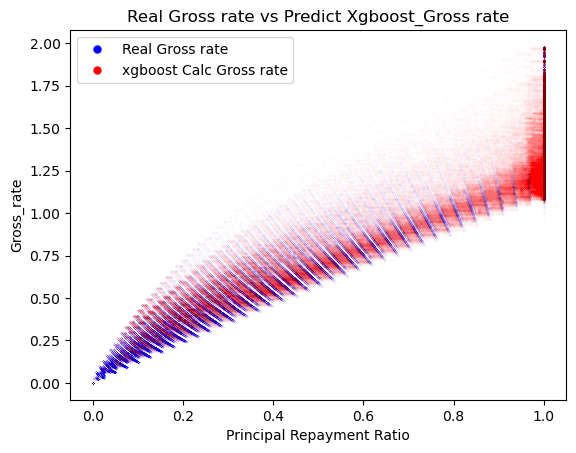

In [88]:
plt.close()
plt.plot(loan_data['target'],loan_data['non_marketing_rate'],label='Real Gross rate', marker='o', linestyle='', color='b',markersize=0.005,alpha=1)
plt.plot(loan_data['predict_xg_target'],loan_data['predict_xgboost_rate'],label='xgboost Calc Gross rate', marker='o', linestyle='', color='r',markersize=0.005)
plt.title('Real Gross rate vs Predict Xgboost_Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel('Gross_rate')
plt.legend(
    loc='best', 
    markerscale=1000, 
)
plt.savefig('/Users/kbh/Downloads/lending club/Gross_diff_xgboost.png',dpi=400)
plt.show()

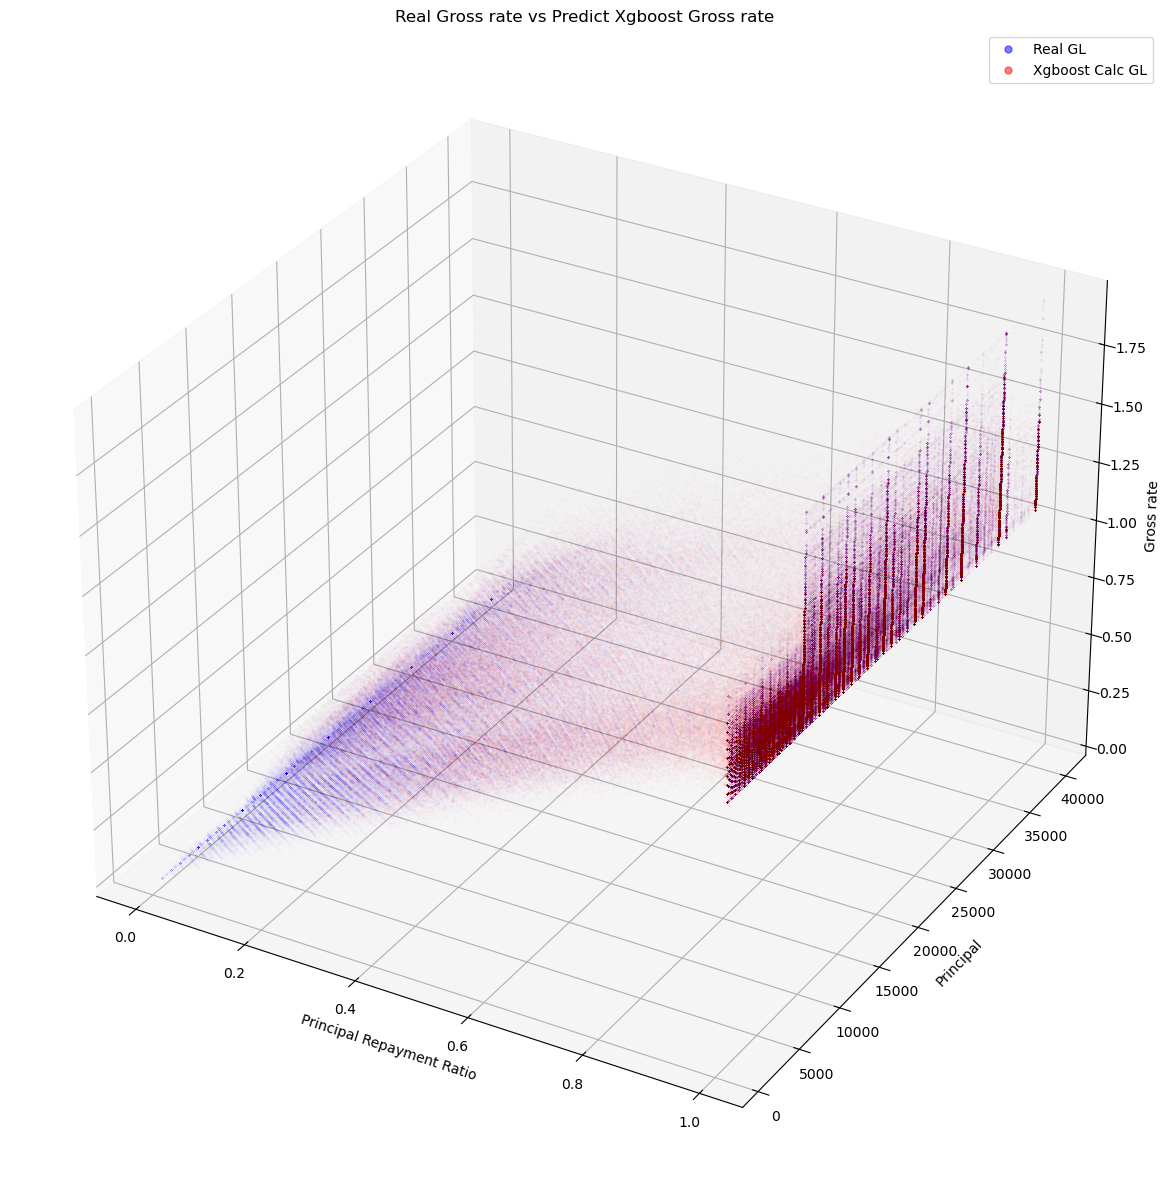

In [92]:
plt.close()
plt.ioff()
fig = plt.figure(figsize=(12 ,12))
ax = fig.add_subplot(111, projection='3d')
ax.plot(loan_data['target'],loan_data['funded_amnt'],loan_data['non_marketing_rate'], label='Real GL',color='b', marker='o', linestyle='', alpha=0.5, markersize=0.01)
ax.plot(loan_data['predict_xg_target'], loan_data['funded_amnt'],loan_data['predict_xgboost_rate'], label='Xgboost Calc GL',color='r', marker='o', linestyle='', alpha=0.5, markersize=0.01)
plt.title('Real Gross rate vs Predict Xgboost Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel("Principal")
ax.set_zlabel('Gross rate')
plt.legend(
    loc='best', 
    markerscale=500, 
)
plt.tight_layout()
# plt.savefig('/Users/kbh/Downloads/lending club/Gross_rate_diff_xgboost_3d.png',dpi=400)
plt.show()

In [94]:
loan_data['predict_xgboost_rate'].mean()

1.128234890838554

In [96]:
loan_data['non_marketing_rate'].mean()

1.0875587468336716